## Re-calibracion

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import least_squares

# =========================================================
# FUNCIONES
# =========================================================

def delta_suave(theta, d1, d2, d3, d4):

    th = np.mod(theta, 2*np.pi)

    theta_nodes = np.array([
        0,
        np.pi/2,
        np.pi,
        3*np.pi/2,
        2*np.pi
    ])

    delta_nodes = np.array([
        d1,
        d2,
        d3,
        d4,
        d1
    ])

    return np.interp(
        th,
        theta_nodes,
        delta_nodes
    )


def model_angulo(
    theta,
    S0,
    S1,
    S2,
    S3,
    d1,
    d2,
    d3,
    d4,
    theta0,
):

    theta = theta + theta0

    delta = delta_suave(
        theta,
        d1,
        d2,
        d3,
        d4
    )

    a0 = (
        S0/2
        + S1/4*(1 + np.cos(delta))
    )

    a4c = (
        S1/4*(1 - np.cos(delta))
    )

    a4s = (
        S2/4*(1 - np.cos(delta))
    )

    a2 = (
        -S3/2*np.sin(delta)
    )

    return (
        a0
        + a2*np.sin(2*theta)
        + a4c*np.cos(4*theta)
        + a4s*np.sin(4*theta)
    )


In [30]:
#theta y deltas libres
def fit_una_vuelta_angulo(theta, I,  titulo=""):

    if titulo != "":
        print(f"\n========== {titulo} ==========\n")

    # =========================================
    # ordenar
    # =========================================

    idx = np.argsort(theta)

    theta = theta[idx]
    I = I[idx]

    # =========================================
    # normalizar
    # =========================================

    I = I / np.max(I)

    S0 = np.max(I)

    # =========================================
    # errores
    # =========================================

    V_div = 0.005

    V_full_scale = 8 * V_div

    res_err = V_full_scale / 256

    I_err = np.sqrt(
        (0.03 * I)**2
        + res_err**2
    )

    # =========================================
    # residuals
    # =========================================

    def residuals(params):

        (
            S1,
            S2,
            S3,
            d1,
            d2,
            d3,
            d4,
            theta0
        ) = params

        I_model = model_angulo(
            theta,
            S0,
            S1,
            S2,
            S3,
            d1,
            d2,
            d3,
            d4,
            theta0
        )

        return (
            I_model - I
        ) / I_err

    # =========================================
    # bounds
    # =========================================

    lower_bounds = [
        -S0,
        -S0,
        -S0,
        1.50,
        1.50,
        1.50,
        1.50,
        -2*np.pi
    ]

    upper_bounds = [
        S0,
        S0,
        S0,
        1.60,
        1.60,
        1.60,
        1.60,
        2*np.pi
    ]

    # =========================================
    # multistart
    # =========================================

    best_result = None
    best_cost = np.inf


    for _ in range(20):

        guess = [

            np.random.uniform(-S0, S0),
            np.random.uniform(-S0, S0),
            np.random.uniform(-S0, S0),

            np.random.uniform(1.50, 1.60),
            np.random.uniform(1.50, 1.60),
            np.random.uniform(1.50, 1.60),
            np.random.uniform(1.50, 1.60),

            np.random.uniform(-np.pi, np.pi)
        ]

        r = least_squares(
            residuals,
            guess,
            bounds=(
                lower_bounds,
                upper_bounds
            )
        )

        if r.cost < best_cost:

            best_cost = r.cost
            best_result = r

    result = best_result


    J = result.jac

    N = len(theta)
    P = len(result.x)

    sigma2 = 2 * result.cost / (N - P)

    cov = sigma2 * np.linalg.pinv(J.T @ J)

    err = np.sqrt(np.diag(cov))

    (
        S1_fit,
        S2_fit,
        S3_fit,
        d1_fit,
        d2_fit,
        d3_fit,
        d4_fit,
        theta0_fit
    ) = result.x

    # =========================================
    # curva ajustada
    # =========================================

    theta_fit = np.linspace(
        0,
        2*np.pi,
        3000
    )

    I_fit = model_angulo(
        theta_fit,
        S0,
        S1_fit,
        S2_fit,
        S3_fit,
        d1_fit,
        d2_fit,
        d3_fit,
        d4_fit,
        theta0_fit
    )

        # =========================================
    # PLOT AJUSTE
    # =========================================

    plt.figure(figsize=(8,5))
    plt.title(titulo)
    plt.plot(
        theta,
        I,
        "o",
        ms=4,
        label="Datos"
    )

    plt.plot(
        theta_fit,
        I_fit,
        lw=2,
        label="Ajuste"
    )

    plt.xlabel(r"$\theta$ [rad]")
    plt.ylabel("Intensidad normalizada")
    plt.grid(True)
    plt.legend()

    # =========================================
    # ESFERA DE POINCARE
    # =========================================

    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection="3d")

    # esfera
    u = np.linspace(0,2*np.pi,60)
    v = np.linspace(0,np.pi,30)

    x = np.outer(np.cos(u),np.sin(v))
    y = np.outer(np.sin(u),np.sin(v))
    z = np.outer(np.ones_like(u),np.cos(v))

    ax.plot_wireframe(
        x,
        y,
        z,
        color="lightgray",
        linewidth=0.5
    )

    # ejes
    ax.plot([-1,1],[0,0],[0,0],'k')
    ax.plot([0,0],[-1,1],[0,0],'k')
    ax.plot([0,0],[0,0],[-1,1],'k')

    # punto medido
    s1 = S1_fit / S0
    s2 = S2_fit / S0
    s3 = S3_fit / S0

    DOP = np.sqrt(
    s1**2 +
    s2**2 +
    s3**2)

    err_s1 = err[0] / S0
    err_s2 = err[1] / S0
    err_s3 = err[2] / S0

    err_DOP = np.sqrt((s1/DOP * err_s1)**2 +(s2/DOP * err_s2)**2 +(s3/DOP * err_s3)**2)

    ax.scatter(
        s1,
        s2,
        s3,
        color="red",
        s=80
    )

    ax.plot(
        [0,s1],
        [0,s2],
        [0,s3],
        color="red"
    )

    ax.set_xlabel(r"$S_1/S_0$")
    ax.set_ylabel(r"$S_2/S_0$")
    ax.set_zlabel(r"$S_3/S_0$")

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])

    ax.set_box_aspect((1,1,1))


    resultados = {

        "s1": s1,
        "s2": s2,
        "s3": s3,

        "err_s1": err_s1,
        "err_s2": err_s2,
        "err_s3": err_s3,

        "DOP": DOP,
        "err_DOP": err_DOP,
        "d1": d1_fit,
        "d2": d2_fit,
        "d3": d3_fit,
        "d4": d4_fit,

        "err_d1": err[3],
        "err_d2": err[4],
        "err_d3": err[5],
        "err_d4": err[6],

        "theta0": theta0_fit,
        "err_theta0": err[7],

        "theta_fit": theta_fit,
        "I_fit": I_fit
    }

    print("\n========== VECTOR DE POINCARÉ ==========")
    print(f"S1/S0 = {s1:.5f} ± {err_s1:.5f}")
    print(f"S2/S0 = {s2:.5f} ± {err_s2:.5f}")
    print(f"S3/S0 = {s3:.5f} ± {err_s3:.5f}")
    print(f"\nDOP = {DOP:.5f} ± {err_DOP:.5f}")

    print("\n========== DELTAS ==========")
    print(f"δ1 = {d1_fit:.5f} ± {err[3]:.5f} rad")
    print(f"δ2 = {d2_fit:.5f} ± {err[4]:.5f} rad")
    print(f"δ3 = {d3_fit:.5f} ± {err[5]:.5f} rad")
    print(f"δ4 = {d4_fit:.5f} ± {err[6]:.5f} rad")

    print(f"\nθ0 = {theta0_fit:.5f} ± {err[7]:.5f} rad")

    return resultados

In [29]:
#theta fijo y deltas libres
def fit_una_vuelta_angulo_thetafijo(theta, I, theta0_fijo, titulo=""):

    if titulo != "":
        print(f"\n========== {titulo} ==========\n")

    # =========================================
    # ordenar
    # =========================================

    idx = np.argsort(theta)

    theta = theta[idx]
    I = I[idx]

    # =========================================
    # normalizar
    # =========================================

    I = I / np.max(I)

    S0 = np.max(I)

    # =========================================
    # errores
    # =========================================

    V_div = 0.005

    V_full_scale = 8 * V_div

    res_err = V_full_scale / 256

    I_err = np.sqrt(
        (0.03 * I)**2
        + res_err**2
    )

    # =========================================
    # residuals
    # =========================================

    def residuals(params):

        (
            S1,
            S2,
            S3,
            d1,
            d2,
            d3,
            d4
        ) = params

        I_model = model_angulo(
            theta,
            S0,
            S1,
            S2,
            S3,
            d1,
            d2,
            d3,
            d4,
            theta0_fijo
        )

        return (
            I_model - I
        ) / I_err

    # =========================================
    # bounds
    # =========================================

    lower_bounds = [
        -S0,
        -S0,
        -S0,
        1.50,
        1.50,
        1.50,
        1.50,]

    upper_bounds = [
        S0,
        S0,
        S0,
        1.60,
        1.60,
        1.60,
        1.60,]

    # =========================================
    # multistart
    # =========================================

    best_result = None
    best_cost = np.inf

    for _ in range(20):

        guess = [

        np.random.uniform(-S0, S0),
        np.random.uniform(-S0, S0),
        np.random.uniform(-S0, S0),

        np.random.uniform(1.50, 1.60),
        np.random.uniform(1.50, 1.60),
        np.random.uniform(1.50, 1.60),
        np.random.uniform(1.50, 1.60)]
        
        r = least_squares(
            residuals,
            guess,
            bounds=(
                lower_bounds,
                upper_bounds
            )
        )

        if r.cost < best_cost:

            best_cost = r.cost
            best_result = r

    result = best_result


    J = result.jac

    N = len(theta)
    P = len(result.x)

    sigma2 = 2 * result.cost / (N - P)

    cov = sigma2 * np.linalg.pinv(J.T @ J)

    err = np.sqrt(np.diag(cov))

    (
        S1_fit,
        S2_fit,
        S3_fit,
        d1_fit,
        d2_fit,
        d3_fit,
        d4_fit
    ) = result.x

    theta0_fit=theta0_fijo

    # =========================================
    # curva ajustada
    # =========================================

    theta_fit = np.linspace(
        0,
        2*np.pi,
        3000
    )

    I_fit = model_angulo(
        theta_fit,
        S0,
        S1_fit,
        S2_fit,
        S3_fit,
        d1_fit,
        d2_fit,
        d3_fit,
        d4_fit,
        theta0_fit
    )

        # =========================================
    # PLOT AJUSTE
    # =========================================

    plt.figure(figsize=(8,5))
    plt.title(titulo)
    plt.plot(
        theta,
        I,
        "o",
        ms=4,
        label="Datos"
    )

    plt.plot(
        theta_fit,
        I_fit,
        lw=2,
        label="Ajuste"
    )

    plt.xlabel(r"$\theta$ [rad]")
    plt.ylabel("Intensidad normalizada")
    plt.grid(True)
    plt.legend()

    # =========================================
    # ESFERA DE POINCARE
    # =========================================

    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection="3d")

    # esfera
    u = np.linspace(0,2*np.pi,60)
    v = np.linspace(0,np.pi,30)

    x = np.outer(np.cos(u),np.sin(v))
    y = np.outer(np.sin(u),np.sin(v))
    z = np.outer(np.ones_like(u),np.cos(v))

    ax.plot_wireframe(
        x,
        y,
        z,
        color="lightgray",
        linewidth=0.5
    )

    # ejes
    ax.plot([-1,1],[0,0],[0,0],'k')
    ax.plot([0,0],[-1,1],[0,0],'k')
    ax.plot([0,0],[0,0],[-1,1],'k')

    # punto medido
    s1 = S1_fit / S0
    s2 = S2_fit / S0
    s3 = S3_fit / S0

    DOP = np.sqrt(
    s1**2 +
    s2**2 +
    s3**2)

    err_s1 = err[0] / S0
    err_s2 = err[1] / S0
    err_s3 = err[2] / S0

    err_DOP = np.sqrt((s1/DOP * err_s1)**2 +(s2/DOP * err_s2)**2 +(s3/DOP * err_s3)**2)

    ax.scatter(
        s1,
        s2,
        s3,
        color="red",
        s=80
    )

    ax.plot(
        [0,s1],
        [0,s2],
        [0,s3],
        color="red"
    )

    ax.set_xlabel(r"$S_1/S_0$")
    ax.set_ylabel(r"$S_2/S_0$")
    ax.set_zlabel(r"$S_3/S_0$")

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])

    ax.set_box_aspect((1,1,1))


    resultados = {

        "s1": s1,
        "s2": s2,
        "s3": s3,

        "err_s1": err_s1,
        "err_s2": err_s2,
        "err_s3": err_s3,

        "DOP": DOP,
        "err_DOP": err_DOP,
        "d1": d1_fit,
        "d2": d2_fit,
        "d3": d3_fit,
        "d4": d4_fit,

        "err_d1": err[3],
        "err_d2": err[4],
        "err_d3": err[5],
        "err_d4": err[6],

        "theta0": theta0_fijo,
        "theta_fit": theta_fit,
        "err_theta0": 0
    }

    print("\n========== VECTOR DE POINCARÉ ==========")
    print(f"S1/S0 = {s1:.5f} ± {err_s1:.5f}")
    print(f"S2/S0 = {s2:.5f} ± {err_s2:.5f}")
    print(f"S3/S0 = {s3:.5f} ± {err_s3:.5f}")
    print(f"\nDOP = {DOP:.5f} ± {err_DOP:.5f}")

    print("\n========== DELTAS ==========")
    print(f"δ1 = {d1_fit:.5f} ± {err[3]:.5f} rad")
    print(f"δ2 = {d2_fit:.5f} ± {err[4]:.5f} rad")
    print(f"δ3 = {d3_fit:.5f} ± {err[5]:.5f} rad")
    print(f"δ4 = {d4_fit:.5f} ± {err[6]:.5f} rad")

    print(f"\nθ0 = {theta0_fijo:.5f} ± {0} rad")

    return resultados

In [26]:
#theta y deltas fijos 
def fit_una_vuelta_angulo_fijos(theta, I,
        theta0_fijo,
        d1_fijo,
        d2_fijo,
        d3_fijo,
        d4_fijo,  titulo=""):

    if titulo != "":
        print(f"\n========== {titulo} ==========\n")

    # =========================================
    # ordenar
    # =========================================

    idx = np.argsort(theta)

    theta = theta[idx]
    I = I[idx]

    # =========================================
    # normalizar
    # =========================================

    I = I / np.max(I)

    S0 = np.max(I)

    # =========================================
    # errores
    # =========================================

    V_div = 0.005

    V_full_scale = 8 * V_div

    res_err = V_full_scale / 256

    I_err = np.sqrt(
        (0.03 * I)**2
        + res_err**2
    )

    # =========================================
    # residuals
    # =========================================

    def residuals(params):

        (
            S1,
            S2,
            S3) = params

        I_model = model_angulo(
            theta,
            S0,
            S1,
            S2,
            S3,
            d1_fijo,
            d2_fijo,
            d3_fijo,
            d4_fijo,
            theta0_fijo
        )

        return (
            I_model - I
        ) / I_err

    # =========================================
    # bounds
    # =========================================

    lower_bounds = [
        -S0,
        -S0,
        -S0
    ]

    upper_bounds = [
        S0,
        S0,
        S0
    ]

    # =========================================
    # multistart
    # =========================================

    best_result = None
    best_cost = np.inf

    for _ in range(20):

        guess = [

            np.random.uniform(-S0, S0),
            np.random.uniform(-S0, S0),
            np.random.uniform(-S0, S0)
        ]

        r = least_squares(
            residuals,
            guess,
            bounds=(
                lower_bounds,
                upper_bounds
            )
        )

        if r.cost < best_cost:

            best_cost = r.cost
            best_result = r

    result = best_result


    J = result.jac

    N = len(theta)
    P = len(result.x)

    sigma2 = 2 * result.cost / (N - P)

    cov = sigma2 * np.linalg.pinv(J.T @ J)

    err = np.sqrt(np.diag(cov))

    (
        S1_fit,
        S2_fit,
        S3_fit
    ) = result.x

    # =========================================
    # curva ajustada
    # =========================================

    theta_fit = np.linspace(
    0,
    2*np.pi,
    3000)

    I_fit = model_angulo(
        theta_fit,
        S0,
        S1_fit,
        S2_fit,
        S3_fit,
        d1_fijo,
        d2_fijo,
        d3_fijo,
        d4_fijo,
        theta0_fijo
    )

        # =========================================
    # PLOT AJUSTE
    # =========================================

    plt.figure(figsize=(8,5))
    plt.title(titulo)
    plt.plot(
        theta,
        I,
        "o",
        ms=4,
        label="Datos"
    )

    plt.plot(
        theta_fit,
        I_fit,
        lw=2,
        label="Ajuste"
    )

    plt.xlabel(r"$\theta$ [rad]")
    plt.ylabel("Intensidad normalizada")
    plt.grid(True)
    plt.legend()

    # =========================================
    # ESFERA DE POINCARE
    # =========================================

    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection="3d")

    # esfera
    u = np.linspace(0,2*np.pi,60)
    v = np.linspace(0,np.pi,30)

    x = np.outer(np.cos(u),np.sin(v))
    y = np.outer(np.sin(u),np.sin(v))
    z = np.outer(np.ones_like(u),np.cos(v))

    ax.plot_wireframe(
        x,
        y,
        z,
        color="lightgray",
        linewidth=0.5
    )

    # ejes
    ax.plot([-1,1],[0,0],[0,0],'k')
    ax.plot([0,0],[-1,1],[0,0],'k')
    ax.plot([0,0],[0,0],[-1,1],'k')

    # punto medido
    s1 = S1_fit / S0
    s2 = S2_fit / S0
    s3 = S3_fit / S0

    DOP = np.sqrt(
    s1**2 +
    s2**2 +
    s3**2)

    err_s1 = err[0] / S0
    err_s2 = err[1] / S0
    err_s3 = err[2] / S0

    err_DOP = np.sqrt((s1/DOP * err_s1)**2 +(s2/DOP * err_s2)**2 +(s3/DOP * err_s3)**2)

    ax.scatter(
        s1,
        s2,
        s3,
        color="red",
        s=80
    )

    ax.plot(
        [0,s1],
        [0,s2],
        [0,s3],
        color="red"
    )

    ax.set_xlabel(r"$S_1/S_0$")
    ax.set_ylabel(r"$S_2/S_0$")
    ax.set_zlabel(r"$S_3/S_0$")

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])

    ax.set_box_aspect((1,1,1))


    resultados = {

        "s1": s1,
        "s2": s2,
        "s3": s3,

        "err_s1": err_s1,
        "err_s2": err_s2,
        "err_s3": err_s3,

        "DOP": DOP,
        "err_DOP": err_DOP,
        "d1": d1_fijo,
        "d2": d2_fijo,
        "d3": d3_fijo,
        "d4": d4_fijo,

        "err_d1": 0,
        "err_d2": 0,
        "err_d3": 0,
        "err_d4": 0,

        "theta0": theta0_fijo,
        "err_theta0": 0,
        "I_fit": I_fit,"theta_fit": theta_fit
    }

    print("\n========== VECTOR DE POINCARÉ ==========")
    print(f"S1/S0 = {s1:.5f} ± {err_s1:.5f}")
    print(f"S2/S0 = {s2:.5f} ± {err_s2:.5f}")
    print(f"S3/S0 = {s3:.5f} ± {err_s3:.5f}")
    print(f"\nDOP = {DOP:.5f} ± {err_DOP:.5f}")

    print("\n========== DELTAS ==========")
    print(f"δ1 = {d1_fijo:.5f}" )
    print(f"δ2 = {d2_fijo:.5f}" )
    print(f"δ3 = {d3_fijo:.5f}" )
    print(f"δ4 = {d4_fijo:.5f}" )

    print(f"\nθ0 = {theta0_fijo:.5f} ±0) rad")

    return resultados

In [27]:
ruta = r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_22.5"

dfs1 = []

for i in range(0, 48, 3):

    nombre1 = f"{ruta}\\bloque_{i:04d}_{i+2:04d}.csv"

    dfs1.append(pd.read_csv(nombre1))

### Para procesar todo

In [18]:
# theta_common = np.linspace(0, 2*np.pi, 500)

# resultados_bloques = []
# S1_all = []
# S2_all = []
# S3_all = []

# errS1_all = []
# errS2_all = []
# errS3_all = []


# delta_all=[]
# theta0_all=[]
# DOP_all = []

# for ib, df in enumerate(dfs1, start=1):

#     print(f"\n================ BLOQUE {ib} ================\n")

#     time = df["tiempo_us"].to_numpy()
#     voltaje = df["voltaje_V"].to_numpy()
#     vueltas = df["vuelta"].to_numpy()

#     vueltas_unicas = np.unique(vueltas)

#     # Número de puntos de cada vuelta
#     puntos_vuelta = {
#         v: np.sum(vueltas == v)
#         for v in vueltas_unicas
#     }

#     max_puntos = max(puntos_vuelta.values())

#     umbral = 0.9 * max_puntos

#     print(f"Vuelta más larga: {max_puntos} puntos")
#     print(f"Umbral de aceptación: {umbral:.0f} puntos\n")

#     I_all = []

#     vueltas_utilizadas = []

#     for v in vueltas_unicas:

#         mask = vueltas == v

#         t = time[mask]
#         I = voltaje[mask]

#         if len(t) < umbral:
#             print(f"Descartando vuelta {v} ({len(t)} puntos)")
#             continue

#         print(f"Usando vuelta {v} ({len(t)} puntos)")

#         idx = np.argsort(t)

#         t = t[idx]
#         I = I[idx]

#         theta = 2*np.pi*(t-t.min())/(t.max()-t.min())

#         I_interp = np.interp(
#             theta_common,
#             theta,
#             I
#         )

#         I_all.append(I_interp)
#         vueltas_utilizadas.append(v)

#     if len(I_all) == 0:
#         print("\nNo quedó ninguna vuelta válida.")
#         continue

#     I_all = np.array(I_all)

#     I_mean = np.mean(I_all, axis=0)
#     I_std = np.std(I_all, axis=0)

#     print(f"\nAjustando el promedio de las vueltas: {vueltas_utilizadas}\n")

#     resultado = fit_una_vuelta_angulo(theta_common, I_mean, titulo=f"Bloque {ib} - Promedio de vueltas {vueltas_utilizadas}")

#     #lo siguiente lo hago para quedarme con los datos consistentes con la teoria
#     s1=resultado["s1"]
#     s2=resultado["s2"]
#     s3=resultado["s3"]
#     s_norm = np.sqrt(s1**2 + s2**2 + s3**2)
#     dop=resultado["DOP"]

#     if dop < 0.9:
#         print(f"Bloque {ib} descartado: DOP bajo ({dop:.3f})")
#         continue

#     if s_norm < 0.7 or s_norm > 1.3:
#         print(f"Bloque {ib} descartado: Stokes no físico ({s_norm:.3f})")
#         continue

#     delta_all.append([resultado["d1"], resultado["d2"], resultado["d3"], resultado["d4"]])
#     theta0_all.append(resultado["theta0"])

#     S1_all.append(s1)
#     S2_all.append(s2)
#     S3_all.append(s3)

#     errS1_all.append(resultado["err_s1"])
#     errS2_all.append(resultado["err_s2"])
#     errS3_all.append(resultado["err_s3"])
    
#     DOP_all.append(resultado["DOP"])
#     resultados_bloques.append(resultado)

# nombre_carpeta = "max"      # o el nombre que quieras que aparezca

# s1_max = np.mean(S1_all)
# s2_max = np.mean(S2_all)
# s3_max = np.mean(S3_all)

# s_max=np.array([np.mean(S1_all),np.mean(S2_all),np.mean(S3_all)])

### Para procesar un bloque en particular

Vuelta más larga: 78 puntos
Umbral de aceptación: 70 puntos

Usando vuelta 935 (77 puntos)
Usando vuelta 936 (78 puntos)
Descartando vuelta 937 (1 puntos)

========== Bloque 11 ==========


========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.64044 ± 0.00495
S2/S0 = 0.98619 ± 0.00997
S3/S0 = -0.07241 ± 0.00379

DOP = 1.17812 ± 0.00877

========== DELTAS ==========
δ1 = 1.60000 ± 0.01407 rad
δ2 = 1.57575 ± 0.01389 rad
δ3 = 1.59430 ± 0.01455 rad
δ4 = 1.55664 ± 0.01388 rad

θ0 = 0.00000 ± 0 rad


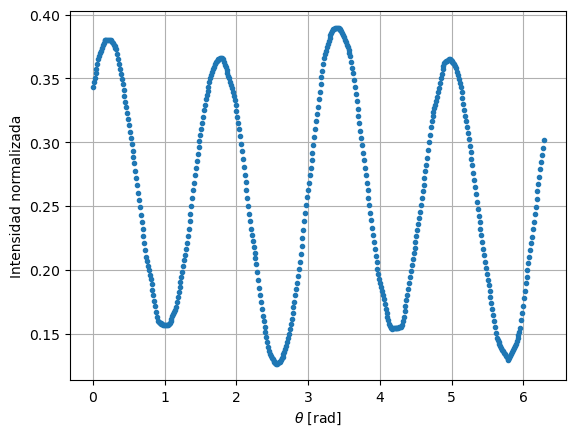

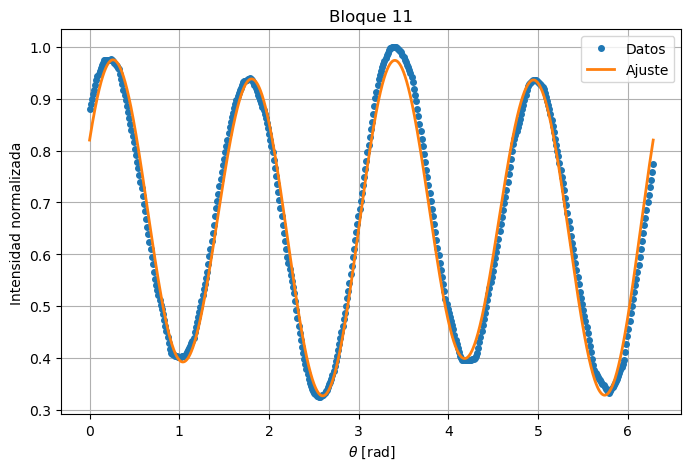

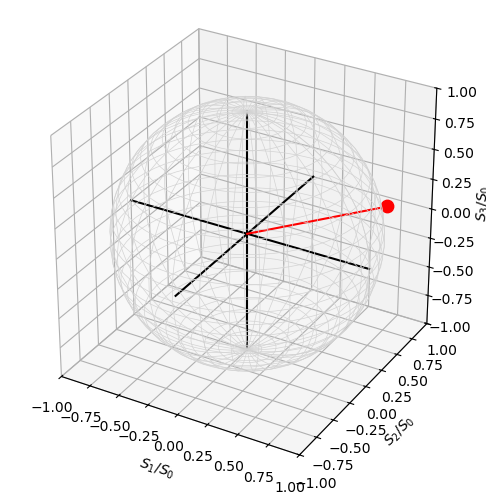

In [ ]:
df=dfs1[10]   
theta_common = np.linspace(0, 2*np.pi, 500)

time = df["tiempo_us"].to_numpy()
voltaje = df["voltaje_V"].to_numpy()
vueltas = df["vuelta"].to_numpy()

vueltas_unicas = np.unique(vueltas)

# Número de puntos de cada vuelta
puntos_vuelta = {
    v: np.sum(vueltas == v)
    for v in vueltas_unicas
}

max_puntos = max(puntos_vuelta.values())

umbral = 0.9 * max_puntos

print(f"Vuelta más larga: {max_puntos} puntos")
print(f"Umbral de aceptación: {umbral:.0f} puntos\n")

I_all = []

vueltas_utilizadas = []

for v in vueltas_unicas:

    mask = vueltas == v

    t = time[mask]
    I = voltaje[mask]

    if len(t) < umbral:
        print(f"Descartando vuelta {v} ({len(t)} puntos)")
        continue

    print(f"Usando vuelta {v} ({len(t)} puntos)")

    idx = np.argsort(t)

    t = t[idx]
    I = I[idx]

    theta = 2*np.pi*(t-t.min())/(t.max()-t.min())

    I_interp = np.interp(
        theta_common,
        theta,
        I
    )

    I_all.append(I_interp)
    vueltas_utilizadas.append(v)

if len(I_all) == 0:
    print("\nNo quedó ninguna vuelta válida.")
    raise SystemExit

I_all = np.array(I_all)

I_mean = np.mean(I_all, axis=0)
I_std = np.std(I_all, axis=0)

plt.plot(theta_common,I_mean,".")
plt.grid()
plt.xlabel(r"$\theta$ [rad]")
plt.ylabel("Intensidad normalizada")

resultado = fit_una_vuelta_angulo_thetafijo(theta_common, I_mean,theta0_fijo=0, titulo=f"Bloque 11")

## Uso calibracion para otras configuraciones

In [34]:
#usamos que ppr la calibracion definimos:

theta0_cal = 0.00000

d1_cal = 1.60000
d2_cal = 1.57575
d3_cal = 1.59430
d4_cal = 1.55664

err_theta0_cal = 0.00000

err_d1_cal = 0.01407
err_d2_cal = 0.01389
err_d3_cal = 0.01455
err_d4_cal = 0.01388

### Caso 0grad

Vuelta más larga: 78 puntos
Umbral de aceptación: 70 puntos

Usando vuelta 727 (78 puntos)
Usando vuelta 728 (78 puntos)
Descartando vuelta 729 (1 puntos)


Text(0, 0.5, 'Intensidad normalizada')

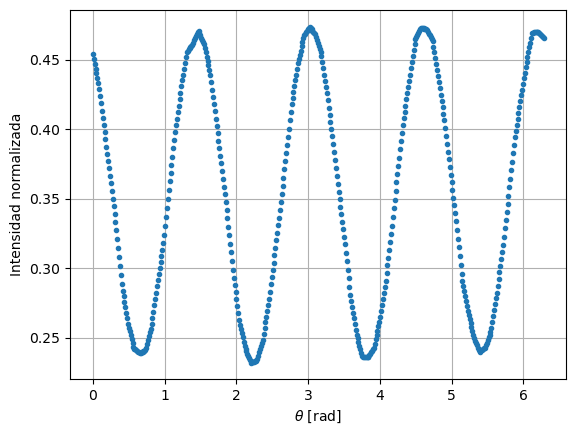

In [36]:
ruta2 = r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_max"

dfs2 = []

for i in range(0, 48, 3):

    nombre2 = f"{ruta2}\\bloque_{i:04d}_{i+2:04d}.csv"

    dfs2.append(pd.read_csv(nombre2))

df=dfs2[6]   
theta_common2 = np.linspace(0, 2*np.pi, 500)

time = df["tiempo_us"].to_numpy()
voltaje = df["voltaje_V"].to_numpy()
vueltas = df["vuelta"].to_numpy()

vueltas_unicas = np.unique(vueltas)

# Número de puntos de cada vuelta
puntos_vuelta = {
    v: np.sum(vueltas == v)
    for v in vueltas_unicas
}

max_puntos = max(puntos_vuelta.values())

umbral = 0.9 * max_puntos

print(f"Vuelta más larga: {max_puntos} puntos")
print(f"Umbral de aceptación: {umbral:.0f} puntos\n")

I_all2 = []

vueltas_utilizadas = []

for v in vueltas_unicas:

    mask = vueltas == v

    t = time[mask]
    I = voltaje[mask]

    if len(t) < umbral:
        print(f"Descartando vuelta {v} ({len(t)} puntos)")
        continue

    print(f"Usando vuelta {v} ({len(t)} puntos)")

    idx = np.argsort(t)

    t = t[idx]
    I = I[idx]

    theta2 = 2*np.pi*(t-t.min())/(t.max()-t.min())

    I_interp2 = np.interp(
        theta_common2,
        theta2,
        I
    )

    I_all2.append(I_interp2)
    vueltas_utilizadas.append(v)

if len(I_all2) == 0:
    print("\nNo quedó ninguna vuelta válida.")
    raise SystemExit

I_all2 = np.array(I_all2)

I_mean2 = np.mean(I_all2, axis=0)
I_std2 = np.std(I_all2, axis=0)

plt.plot(theta_common2,I_mean2,".")
plt.grid()
plt.xlabel(r"$\theta$ [rad]")
plt.ylabel("Intensidad normalizada")

#resultado = fit_una_vuelta_angulo_thetafijo(theta_common2, I_mean2,theta0_fijo=0, titulo=f"Bloque 11")


========== Ajuste configuracion 0 grados ==========


========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.96180 ± 0.00417
S2/S0 = -0.41162 ± 0.00575
S3/S0 = -0.00215 ± 0.00245

DOP = 1.04618 ± 0.00445

========== DELTAS ==========
δ1 = 1.60000
δ2 = 1.57575
δ3 = 1.59430
δ4 = 1.55664

θ0 = 0.00000 ±0) rad


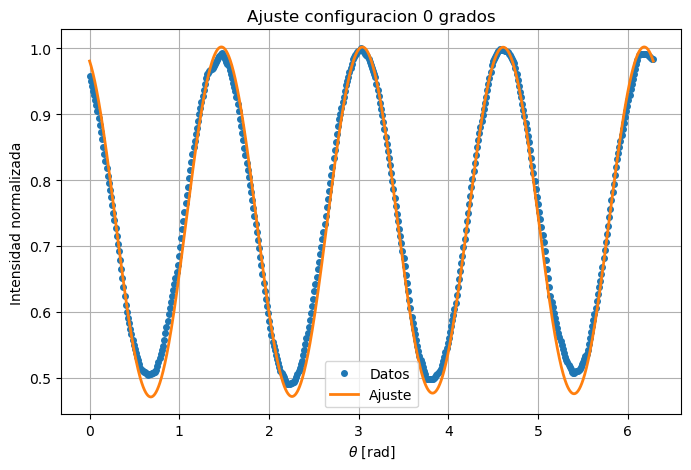

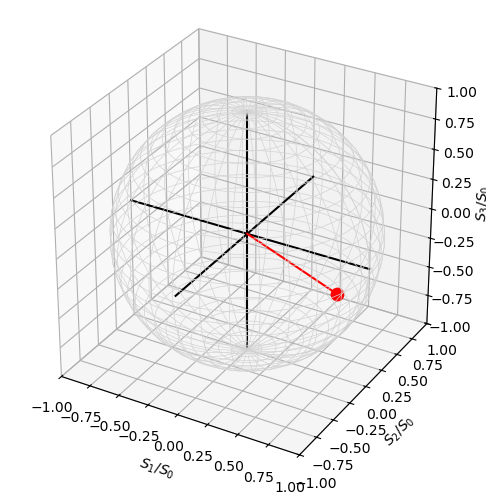

In [37]:
resultado = fit_una_vuelta_angulo_fijos(
    theta_common2,
    I_mean2,
    theta0_cal,
    d1_cal,
    d2_cal,
    d3_cal,
    d4_cal,
    titulo="Ajuste configuracion 0 grados"
)

### Caso 45 

Vuelta más larga: 78 puntos
Umbral de aceptación: 70 puntos

Usando vuelta 821 (78 puntos)
Usando vuelta 822 (78 puntos)
Descartando vuelta 823 (1 puntos)


Text(0, 0.5, 'Intensidad normalizada')

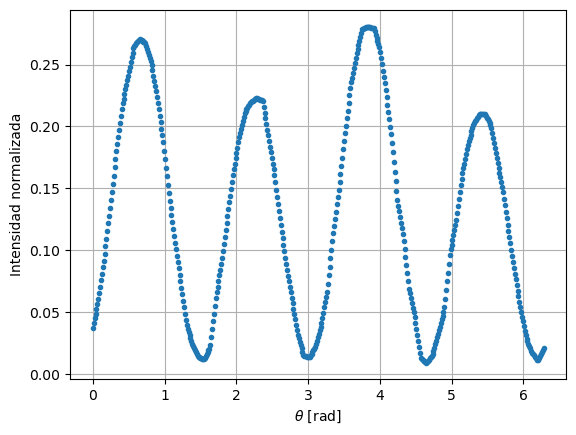

In [40]:
ruta3 = r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_45"

dfs3= []

for i in range(0, 48, 3):

    nombre3 = f"{ruta3}\\bloque_{i:04d}_{i+2:04d}.csv"

    dfs3.append(pd.read_csv(nombre3))

df=dfs3[10]   
theta_common3 = np.linspace(0, 2*np.pi, 500)

time = df["tiempo_us"].to_numpy()
voltaje = df["voltaje_V"].to_numpy()
vueltas = df["vuelta"].to_numpy()

vueltas_unicas = np.unique(vueltas)

# Número de puntos de cada vuelta
puntos_vuelta = {
    v: np.sum(vueltas == v)
    for v in vueltas_unicas
}

max_puntos = max(puntos_vuelta.values())

umbral = 0.9 * max_puntos

print(f"Vuelta más larga: {max_puntos} puntos")
print(f"Umbral de aceptación: {umbral:.0f} puntos\n")

I_all3 = []

vueltas_utilizadas = []

for v in vueltas_unicas:

    mask = vueltas == v

    t = time[mask]
    I = voltaje[mask]

    if len(t) < umbral:
        print(f"Descartando vuelta {v} ({len(t)} puntos)")
        continue

    print(f"Usando vuelta {v} ({len(t)} puntos)")

    idx = np.argsort(t)

    t = t[idx]
    I = I[idx]

    theta3 = 2*np.pi*(t-t.min())/(t.max()-t.min())

    I_interp3 = np.interp(
        theta_common3,
        theta3,
        I
    )

    I_all3.append(I_interp3)
    vueltas_utilizadas.append(v)

if len(I_all3) == 0:
    print("\nNo quedó ninguna vuelta válida.")
    raise SystemExit

I_all3 = np.array(I_all3)

I_mean3 = np.mean(I_all3, axis=0)
I_std3 = np.std(I_all3, axis=0)

plt.plot(theta_common3,I_mean3,".")
plt.grid()
plt.xlabel(r"$\theta$ [rad]")
plt.ylabel("Intensidad normalizada")

#resultado = fit_una_vuelta_angulo_thetafijo(theta_common2, I_mean2,theta0_fijo=0, titulo=f"Bloque 11")


========== Ajuste configuracion 45 grados ==========


========== VECTOR DE POINCARÉ ==========
S1/S0 = -0.86238 ± 0.00566
S2/S0 = 0.36093 ± 0.02265
S3/S0 = -0.03595 ± 0.01508

DOP = 0.93555 ± 0.01019

========== DELTAS ==========
δ1 = 1.60000
δ2 = 1.57575
δ3 = 1.59430
δ4 = 1.55664

θ0 = 0.00000 ±0) rad


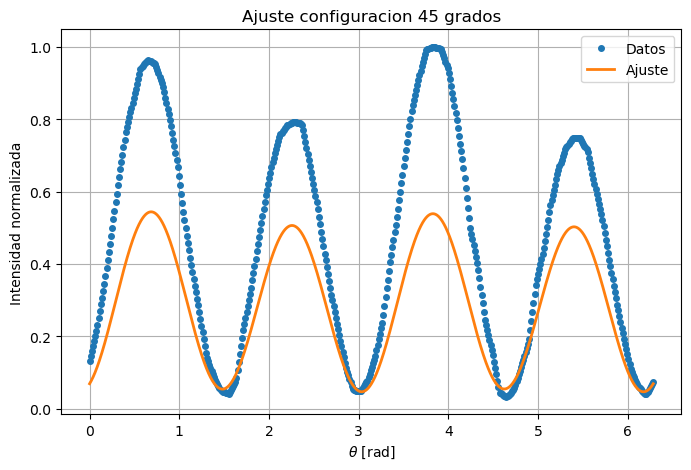

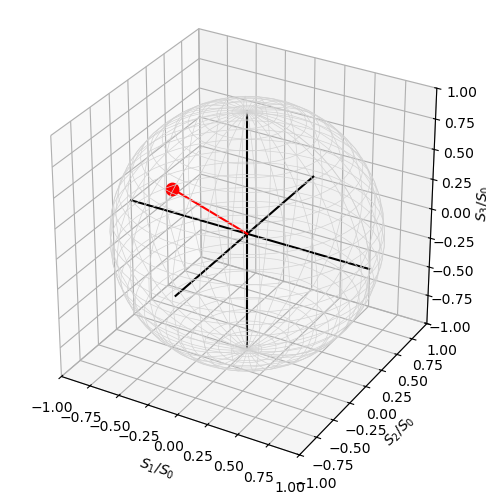

In [41]:
resultado3 = fit_una_vuelta_angulo_fijos(
    theta_common3,
    I_mean3,
    theta0_cal,
    d1_cal,
    d2_cal,
    d3_cal,
    d4_cal,
    titulo="Ajuste configuracion 45 grados"
)

### Caso -22.5

Vuelta más larga: 78 puntos
Umbral de aceptación: 70 puntos

Usando vuelta 1040 (78 puntos)
Usando vuelta 1041 (78 puntos)
Descartando vuelta 1042 (1 puntos)


Text(0, 0.5, 'Intensidad normalizada')

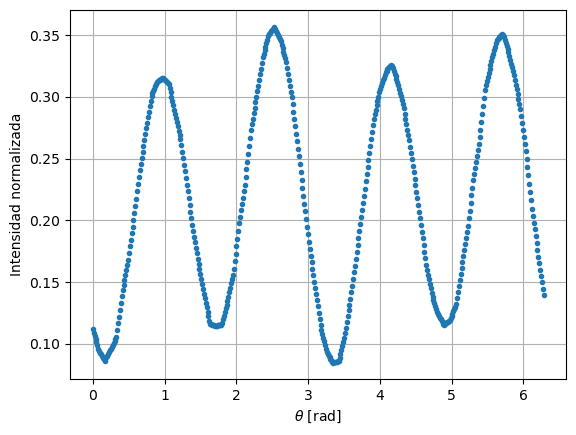

In [42]:
ruta4 = r"C:\Users\barcr\OneDrive\Documents\Polarimetro\mediciones_-225"

dfs4 = []

for i in range(0, 48, 3):

    nombre4 = f"{ruta4}\\bloque_{i:04d}_{i+2:04d}.csv"

    dfs4.append(pd.read_csv(nombre4))

df=dfs4[6]   
theta_common4 = np.linspace(0, 2*np.pi, 500)

time = df["tiempo_us"].to_numpy()
voltaje = df["voltaje_V"].to_numpy()
vueltas = df["vuelta"].to_numpy()

vueltas_unicas = np.unique(vueltas)

# Número de puntos de cada vuelta
puntos_vuelta = {
    v: np.sum(vueltas == v)
    for v in vueltas_unicas
}

max_puntos = max(puntos_vuelta.values())

umbral = 0.9 * max_puntos

print(f"Vuelta más larga: {max_puntos} puntos")
print(f"Umbral de aceptación: {umbral:.0f} puntos\n")

I_all4 = []

vueltas_utilizadas = []

for v in vueltas_unicas:

    mask = vueltas == v

    t = time[mask]
    I = voltaje[mask]

    if len(t) < umbral:
        print(f"Descartando vuelta {v} ({len(t)} puntos)")
        continue

    print(f"Usando vuelta {v} ({len(t)} puntos)")

    idx = np.argsort(t)

    t = t[idx]
    I = I[idx]

    theta4 = 2*np.pi*(t-t.min())/(t.max()-t.min())

    I_interp4 = np.interp(
        theta_common4,
        theta4,
        I
    )

    I_all4.append(I_interp4)
    vueltas_utilizadas.append(v)

if len(I_all4) == 0:
    print("\nNo quedó ninguna vuelta válida.")
    raise SystemExit

I_all4 = np.array(I_all4)

I_mean4 = np.mean(I_all4, axis=0)
I_std4 = np.std(I_all4, axis=0)

plt.plot(theta_common4,I_mean4,".")
plt.grid()
plt.xlabel(r"$\theta$ [rad]")
plt.ylabel("Intensidad normalizada")

#resultado = fit_una_vuelta_angulo_thetafijo(theta_common2, I_mean2,theta0_fijo=0, titulo=f"Bloque 11")


========== Ajuste configuracion 0 grados ==========


========== VECTOR DE POINCARÉ ==========
S1/S0 = -0.17690 ± 0.01775
S2/S0 = -0.63109 ± 0.03806
S3/S0 = 0.07794 ± 0.02197

DOP = 0.66004 ± 0.03679

========== DELTAS ==========
δ1 = 1.60000
δ2 = 1.57575
δ3 = 1.59430
δ4 = 1.55664

θ0 = 0.00000 ±0) rad


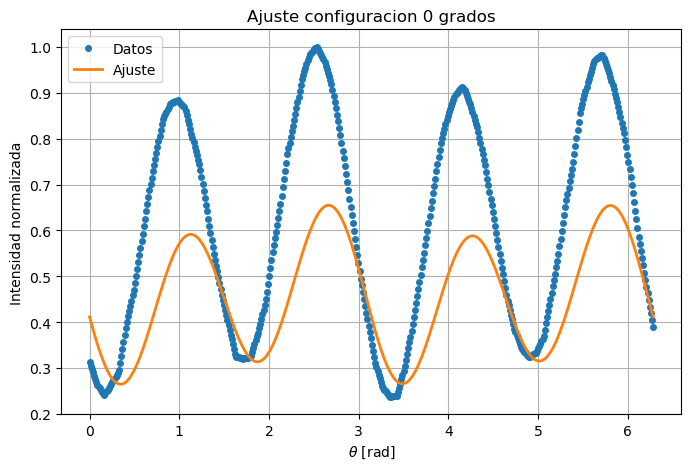

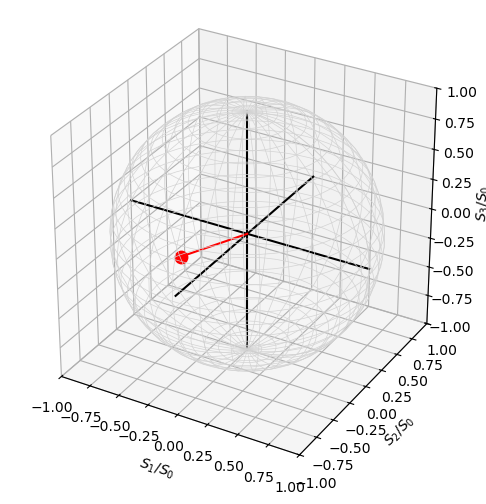

In [43]:
resultado4 = fit_una_vuelta_angulo_fijos(
    theta_common4,
    I_mean4,
    theta0_cal,
    d1_cal,
    d2_cal,
    d3_cal,
    d4_cal,
    titulo="Ajuste configuracion 0 grados"
)

## Simulacion

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from ipywidgets import interact

# =====================================================================
# 1. MODELOS MATEMÁTICOS
# =====================================================================
def delta_suave_sim(theta, d1, d2, d3, d4):
    th = np.mod(theta, 2*np.pi)
    theta_nodes = np.array([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    delta_nodes = np.array([d1, d2, d3, d4, d1])
    return np.interp(th, theta_nodes, delta_nodes)

def modelo_intensidad(theta, S0, S1, S2, S3, d1, d2, d3, d4, theta0):
    th_corr = theta + theta0
    del_val = delta_suave_sim(th_corr, d1, d2, d3, d4)
    I = 0.5 * (S0 + S1 * (np.cos(2*th_corr)**2 + np.sin(2*th_corr)**2 * np.cos(del_val))
                  + S2 * (np.sin(2*th_corr) * np.cos(2*th_corr) * (1 - np.cos(del_val)))
                  - S3 * (np.sin(2*th_corr) * np.sin(del_val)))
    return I

def residuos_libres(p, theta, I_data):
    # Ajuste libre (como tu script actual)
    return modelo_intensidad(theta, *p) - I_data

# =====================================================================
# 2. FUNCIÓN INTERACTIVA PRINCIPAL
# =====================================================================
def simular_y_ajustar(polarizacion_entrada, error_theta0, error_d1, error_d2, error_d3, error_d4):
    # Ángulos de medición de la QWP
    theta_medido = np.linspace(0, 2*np.pi, 100)
    
    # Definir el estado real según la HWP seleccionada
    if polarizacion_entrada == 'HWP 0° (Lineal H)':
        S_real = np.array([1.0, 1.0, 0.0, 0.0])      # S1 = +1 (Horizontal)
    elif polarizacion_entrada == 'HWP 45° (Lineal V)':
        S_real = np.array([1.0, -1.0, 0.0, 0.0])     # S1 = -1 (Vertical)
    elif polarizacion_entrada == 'HWP 22.5° (Lineal +45°)':
        S_real = np.array([1.0, 0.0, 1.0, 0.0])      # S2 = +1 (+45 grados)
    elif polarizacion_entrada == 'HWP -22.5° (Lineal -45°)':
        S_real = np.array([1.0, 0.0, -1.0, 0.0])     # S2 = -1 (-45 grados)
        
    # 1. Generar la intensidad experimental sintética con errores
    th0_rad = np.deg2rad(error_theta0)
    I_exp = modelo_intensidad(theta_medido, *S_real, error_d1, error_d2, error_d3, error_d4, th0_rad)
    
    # 2. Ejecutar el Ajuste dejando parámetros libres (Simula tu problema)
    p0_inicial = [1.0, 0.5, 0.5, 0.0, 1.57, 1.57, 1.57, 1.57, 0.0]
    res = least_squares(residuos_libres, p0_inicial, args=(theta_medido, I_exp))
    S_ajustado = res.x[:4]
    I_ajustada = modelo_intensidad(theta_medido, *res.x)

    # 3. Graficar
    fig = plt.figure(figsize=(12, 5))
    
    # --- GRÁFICO DE INTENSIDAD ---
    ax1 = fig.add_subplot(121)
    ax1.plot(np.rad2deg(theta_medido), I_exp, 'ro', markersize=3, label='Dato Experimental (Simulado)')
    ax1.plot(np.rad2deg(theta_medido), I_ajustada, 'b-', label='Curva del Ajuste')
    ax1.set_title("Señal del Detector (Osciloscopio)")
    ax1.set_xlabel("Ángulo de la QWP (grados)")
    ax1.set_ylabel("Intensidad (V)")
    ax1.set_xlim([0, 360])
    ax1.legend()
    ax1.grid(True)

    # --- ESFERA DE POINCARÉ ---
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.set_title("Esfera de Poincaré")
    
    # Esfera tenue de fondo
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    ax2.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v), color="grey", alpha=0.1)
    
    # Punto Físico Real (Verde)
    ax2.scatter(S_real[1]/S_real[0], S_real[2]/S_real[0], S_real[3]/S_real[0], 
                color='green', s=200, marker='o', label='Estado Físico Real')
    
    # Punto Reconstruido por el Ajuste con error (Cruz Azul)
    ax2.scatter(S_ajustado[1]/S_ajustado[0], S_ajustado[2]/S_ajustado[0], S_ajustado[3]/S_ajustado[0], 
                color='blue', s=120, marker='x', label='Estado Reconstruido')
    
    # Línea al origen
    ax2.plot([0, S_ajustado[1]/S_ajustado[0]], [0, S_ajustado[2]/S_ajustado[0]], [0, S_ajustado[3]/S_ajustado[0]], 'b--')

    ax2.set_xlabel('S1 (H / V)'); ax2.set_ylabel('S2 (+45 / -45)'); ax2.set_zlabel('S3 (Circ)')
    ax2.set_xlim([-1.1, 1.1]); ax2.set_ylim([-1.1, 1.1]); ax2.set_zlim([-1.1, 1.1])
    ax2.legend(loc='lower left')
    
    plt.tight_layout()
    plt.show()
    
    # Imprimir valores
    print(f"Vector Real de Stokes (S1, S2, S3): ({S_real[1]:.2f}, {S_real[2]:.2f}, {S_real[3]:.2f})")
    print(f"Vector Ajustado Reconstruido:       ({S_ajustado[1]/S_ajustado[0]:.2f}, {S_ajustado[2]/S_ajustado[0]:.2f}, {S_ajustado[3]/S_ajustado[0]:.2f})")

# =====================================================================
# 3. INTERFAZ DE USUARIO (BOTONES Y SLIDERS)
# =====================================================================
interact(simular_y_ajustar,
         polarizacion_entrada=widgets.ToggleButtons(
             options=['HWP 0° (Lineal H)', 'HWP 45° (Lineal V)', 'HWP 22.5° (Lineal +45°)', 'HWP -22.5° (Lineal -45°)'], 
             description='Estado Luz:'
         ),
         error_theta0=widgets.FloatSlider(value=0.0, min=-30.0, max=30.0, step=0.5, description='Error θ0 (°)'),
         error_d1=widgets.FloatSlider(value=1.57, min=1.2, max=1.9, step=0.01, description='Delta 1 (rad)'),
         error_d2=widgets.FloatSlider(value=1.57, min=1.2, max=1.9, step=0.01, description='Delta 2 (rad)'),
         error_d3=widgets.FloatSlider(value=1.57, min=1.2, max=1.9, step=0.01, description='Delta 3 (rad)'),
         error_d4=widgets.FloatSlider(value=1.57, min=1.2, max=1.9, step=0.01, description='Delta 4 (rad)')
);

interactive(children=(ToggleButtons(description='Estado Luz:', options=('HWP 0° (Lineal H)', 'HWP 45° (Lineal …